# OVERVIEW

This notebooks serves as an example of how to use associated /src .py files

In [1]:
from pathlib import Path

import pandas as pd

CATALOGUE_PATH = Path(
    "/Users/oscarlewis/Desktop/python/t212_universe/t212_isa_universe.csv"
)

# Candidate instruments for review, not yet the final backtest universe.
CANDIDATE_TICKERS = {
    "US equities": "IUSA",
    "UK equities": "ISF",
    "Europe excluding UK equities": "IEUX",
    "Japan equities": "IJPN",
    "Emerging-market equities": "IEEM",
    "UK conventional gilts": "IGLT",
    "UK inflation-linked gilts": "INXG",
    "GBP corporate bonds": "SLXX",
    "Physical gold": "SGLN",
    "Broad commodities": "CMOP",
}

catalogue = pd.read_csv(CATALOGUE_PATH, dtype="string")

requested = pd.DataFrame(
    CANDIDATE_TICKERS.items(),
    columns=["exposure", "ticker"],
)

matching_rows = catalogue.loc[
    catalogue["ticker"].isin(requested["ticker"])
]

candidate_universe = requested.merge(
    matching_rows,
    on="ticker",
    how="left",
    validate="one_to_one",
)

assert candidate_universe["isin"].notna().all(), "A candidate is missing."

display(
    candidate_universe[
        [
            "exposure",
            "ticker",
            "yf_symbol",
            "name",
            "isin",
            "instrument_type",
            "quote_unit",
            "share_class",
        ]
    ]
)

,exposure,ticker,yf_symbol,name,isin,instrument_type,quote_unit,share_class
0,US equities,IUSA,IUSA.L,iShares Core S&P 500 USD (Dist),IE0031442068,ETF,GBX,Dist
1,UK equities,ISF,ISF.L,iShares Core FTSE 100 (Dist),IE0005042456,ETF,GBX,Dist
2,Europe excluding UK equities,IEUX,IEUX.L,iShares MSCI Europe ex-UK (Dist),IE00B14X4N27,ETF,GBX,Dist
3,Japan equities,IJPN,IJPN.L,iShares MSCI Japan USD (Dist),IE00B02KXH56,ETF,GBX,Dist
4,Emerging-market equities,IEEM,IEEM.L,iShares MSCI EM USD (Dist),IE00B0M63177,ETF,GBX,Dist
5,UK conventional gilts,IGLT,IGLT.L,iShares Core UK Gilts (Dist),IE00B1FZSB30,ETF,GBP,Dist
6,UK inflation-linked gilts,INXG,INXG.L,iShares GBP Index-Linked Gilts (Dist),IE00B1FZSD53,ETF,GBP,Dist
7,GBP corporate bonds,SLXX,SLXX.L,iShares Core GBP Corp Bond (Dist),IE00B00FV011,ETF,GBP,Dist
8,Physical gold,SGLN,SGLN.L,iShares Physical Gold,IE00B4ND3602,ETP,GBX,<NA>
9,Broad commodities,CMOP,CMOP.L,Invesco Bloomberg Commodity (Acc),IE00BD6FTQ80,ETF,GBX,Acc


In [2]:
reviewed_metadata = pd.DataFrame.from_dict(
    {
        "IUSA": ("equity", "ETF", "physical", "Dist"),
        "ISF":  ("equity", "ETF", "physical", "Dist"),
        "IEUX": ("equity", "ETF", "physical", "Dist"),
        "IJPN": ("equity", "ETF", "physical", "Dist"),
        "IEEM": ("equity", "ETF", "physical", "Dist"),
        "IGLT": ("bond", "ETF", "physical", "Dist"),
        "INXG": ("bond", "ETF", "physical", "Dist"),
        "SLXX": ("bond", "ETF", "physical", "Dist"),
        "SGLN": ("commodity", "ETC", "physical_metal", "No income"),
        "CMOP": ("commodity", "ETF", "synthetic_swap", "Acc")
    },orient="index",columns=[
        "asset_group",
        "instrument_type",
        "replication",
        "share_class"],).rename_axis("ticker")

universe = candidate_universe.set_index("ticker").copy()
assert set(universe.index) == set(reviewed_metadata.index)

#pandas aligns these assignments by ticker
universe[reviewed_metadata.columns] = reviewed_metadata
universe.loc["SLXX", "exposure_family"] = "corporate"
universe.loc["SGLN", "research_subclass"] = "etc_commodity"

display(universe[["exposure",
            "asset_group",
            "instrument_type",
            "replication",
            "share_class",
            "quote_unit"]])

,exposure,asset_group,instrument_type,replication,share_class,quote_unit
ticker,,,,,,
IUSA,US equities,equity,ETF,physical,Dist,GBX
ISF,UK equities,equity,ETF,physical,Dist,GBX
IEUX,Europe excluding UK equities,equity,ETF,physical,Dist,GBX
IJPN,Japan equities,equity,ETF,physical,Dist,GBX
IEEM,Emerging-market equities,equity,ETF,physical,Dist,GBX
IGLT,UK conventional gilts,bond,ETF,physical,Dist,GBP
INXG,UK inflation-linked gilts,bond,ETF,physical,Dist,GBP
SLXX,GBP corporate bonds,bond,ETF,physical,Dist,GBP
SGLN,Physical gold,commodity,ETC,physical_metal,No income,GBX


In [3]:
import sys

PROJECT_ROOT = next(
    directory for directory in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (directory / "src" / "etf_data.py").is_file()
)

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

import etf_data

DATA_START = "2000-01-01"
DATA_END = "2026-09-01"  # Exclusive: includes the last completed month.
CACHE_DIR = PROJECT_ROOT / "data" / "raw"

iusa_prices, iusa_metadata = etf_data.load_etf_history(
    universe.loc["IUSA", "yf_symbol"],
    DATA_START,
    DATA_END,
    CACHE_DIR,
)

display(pd.Series(iusa_metadata))
display(iusa_prices.head())
display(iusa_prices.tail())

/Users/oscarlewis/Desktop/python/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


symbol                                         IUSA.L
currency                                          GBp
exchange_timezone                       Europe/London
downloaded_at_utc    2026-09-15T20:14:18.442062+00:00
yfinance_version                                1.2.0
dtype: object

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,,
2009-01-02,621.5,635.0,621.0,635.0,633.912842,318431,0.0,0.0,0.0
2009-01-05,642.0,643.0,635.0,638.5,637.406616,561042,0.0,0.0,0.0
2009-01-06,635.0,647.5,632.0,632.0,630.918091,400592,0.0,0.0,0.0
2009-01-07,624.5,625.0,601.0,603.5,602.466553,795643,0.0,0.0,0.0
2009-01-08,601.5,606.5,587.5,593.5,592.483704,1436452,0.0,0.0,0.0


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,,
2026-08-24,5594.00,5609.75,5585.250000,5593.25,5593.25,40587,0.0,0.0,0.0
2026-08-25,5614.50,5623.75,5596.000000,5605.75,5605.75,39663,0.0,0.0,0.0
2026-08-26,5609.75,5636.00,5603.750000,5625.25,5625.25,74289,0.0,0.0,0.0
2026-08-27,5651.00,5672.00,5638.975098,5665.50,5665.50,43621,0.0,0.0,0.0
2026-08-28,5671.75,5712.00,5666.000000,5707.25,5707.25,104782,0.0,0.0,0.0


In [4]:
histories = {}
history_metadata = {}
coverage_records = []

price_columns = ["Open", "High", "Low", "Close", "Adj Close"]

for ticker, symbol in universe["yf_symbol"].items():
    print(f"Loading {ticker}...")

    try:
        prices, metadata = etf_data.load_etf_history(
            symbol,
            DATA_START,
            DATA_END,
            CACHE_DIR,
        )
    except Exception as exc:
        coverage_records.append({
            "ticker": ticker,
            "status": "failed",
            "error": str(exc),
        })
        continue

    histories[ticker] = prices
    history_metadata[ticker] = metadata

    complete_prices = prices[price_columns].notna().all(axis=1)
    complete_dates = prices.index[complete_prices]

    coverage_records.append({
        "ticker": ticker,
        "status": "loaded",
        "rows": len(prices),
        "first_complete_date": complete_dates.min(),
        "last_complete_date": complete_dates.max(),
        "incomplete_price_rows": int((~complete_prices).sum()),
        "yahoo_currency": metadata["currency"],
        "error": "",
    })

coverage = pd.DataFrame(coverage_records).set_index("ticker")

display(coverage)
print(f"Loaded: {len(histories)} / {len(universe)} instruments")

Loading IUSA...
Loading ISF...
Loading IEUX...
Loading IJPN...
Loading IEEM...
Loading IGLT...
Loading INXG...
Loading SLXX...
Loading SGLN...
Loading CMOP...


,status,rows,first_complete_date,last_complete_date,incomplete_price_rows,yahoo_currency,error
ticker,,,,,,,
IUSA,loaded,4461,2009-01-02,2026-08-28,2,GBp,
ISF,loaded,4461,2009-01-02,2026-08-28,1,GBp,
IEUX,loaded,4461,2009-01-02,2026-08-28,2,GBp,
IJPN,loaded,4461,2009-01-02,2026-08-28,1,GBp,
IEEM,loaded,4461,2009-01-02,2026-08-28,2,GBp,
IGLT,loaded,4715,2008-01-02,2026-08-28,1,GBP,
INXG,loaded,4715,2008-01-02,2026-08-28,1,GBP,
SLXX,loaded,4715,2008-01-02,2026-08-28,1,GBP,
SGLN,loaded,3887,2011-04-08,2026-08-28,0,GBp,


Loaded: 10 / 10 instruments


In [5]:
import importlib

importlib.reload(etf_data)

history_audit = pd.DataFrame({
    ticker: etf_data.audit_etf_history(prices)
    for ticker, prices in histories.items()
}).T.rename_axis("ticker")

display(history_audit)

/Users/oscarlewis/Desktop/python/.venv/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/oscarlewis/Desktop/python/.venv/lib/python3.9/site-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,duplicate_dates,incomplete_price_rows,zero_volume_rows,large_close_moves,dividend_events,first_dividend_date,median_adjustment_ratio
ticker,,,,,,,
IUSA,0,2,4,0,50,2014-02-26 00:00:00,0.010005
ISF,0,1,2,0,54,2013-02-20 00:00:00,0.010001
IEUX,0,2,6,0,50,2014-02-26 00:00:00,0.009994
IJPN,0,1,7,2,26,2014-05-21 00:00:00,0.009999
IEEM,0,2,3,0,50,2014-02-26 00:00:00,0.010004
IGLT,0,1,259,0,28,2013-04-24 00:00:00,1.000001
INXG,0,1,258,0,22,2013-04-24 00:00:00,1.0
SLXX,0,1,258,0,54,2013-02-20 00:00:00,0.999998
SGLN,0,0,26,21,0,NaT,NaN


In [ ]:
importlib.reload(etf_data)

REPAIRED_CACHE_DIR = PROJECT_ROOT / "data" / "repaired"

repaired_histories = {}
repaired_metadata = {}

for ticker, symbol in universe["yf_symbol"].items():
    print(f"Loading repaired history: {ticker}...")

    prices, metadata = etf_data.load_etf_history(
        symbol,
        DATA_START,
        DATA_END,
        REPAIRED_CACHE_DIR,
        repair=True
    )

    repaired_histories[ticker] = prices
    repaired_metadata[ticker] = metadata

repaired_audit = pd.DataFrame({
    ticker: etf_data.audit_etf_history(prices)
    for ticker, prices in repaired_histories.items()
}).T.rename_axis("ticker")

audit_comparison = pd.concat(
    {"raw": history_audit, "repaired": repaired_audit},
    names=["version"],
).swaplevel("version", "ticker").sort_index()

display(
    audit_comparison[
        [
            "incomplete_price_rows",
            "large_close_moves",
            "dividend_events",
            "median_adjustment_ratio",
        ]
    ]
)

display(pd.DataFrame({
    "raw_currency": {
        ticker: metadata["currency"]
        for ticker, metadata in history_metadata.items()
    },
    "repaired_currency": {
        ticker: metadata["currency"]
        for ticker, metadata in repaired_metadata.items()
    },
}))

Loading repaired history: IUSA...
Loading repaired history: ISF...
Loading repaired history: IEUX...
Loading repaired history: IJPN...
Loading repaired history: IEEM...
Loading repaired history: IGLT...
Loading repaired history: INXG...
Loading repaired history: SLXX...
Loading repaired history: SGLN...
Loading repaired history: CMOP...


incomplete_price_rows large_close_moves dividend_events  \
ticker version                                                            
CMOP   raw                          3                 2               0   
       repaired                     2                 2               0   
IEEM   raw                          2                 0              50   
       repaired                     0                 0              50   
IEUX   raw                          2                 0              50   
       repaired                     0                 0              50   
IGLT   raw                          1                 0              28   
       repaired                     0                 0              27   
IJPN   raw                          1                 2              26   
       repaired                     0                 2              26   
INXG   raw                          1                 0              22   
       repaired                     0                 0              22   
ISF    raw                          1                 0              54   
       repaired                     0                 0              54   
IUSA   raw                          2                 0              50   
       repaired                     0                 0              50   
SGLN   raw                          0                21               0   
       repaired                     0                21               0   
SLXX   raw                          1                 0              54   
       repaired                     0                 0              54   

                median_adjustment_ratio  
ticker version                           
CMOP   raw                          NaN  
       repaired                     NaN  
IEEM   raw                     0.010004  
       repaired                     1.0  
IEUX   raw                     0.009994  
       repaired                     1.0  
IGLT   raw                     1.000001  
       repaired                1.000001  
IJPN   raw                     0.009999  
       repaired                     1.0  
INXG   raw                          1.0  
       repaired                     1.0  
ISF    raw                     0.010001  
       repaired                     1.0  
IUSA   raw                     0.010005  
       repaired                     1.0  
SGLN   raw                          NaN  
       repaired                     NaN  
SLXX   raw                     0.999998  
       repaired                0.999998

,raw_currency,repaired_currency
IUSA,GBp,GBP
ISF,GBp,GBP
IEUX,GBp,GBP
IJPN,GBp,GBP
IEEM,GBp,GBP
IGLT,GBP,GBP
INXG,GBP,GBP
SLXX,GBP,GBP
SGLN,GBp,GBP
CMOP,GBp,GBP


In [8]:
unit_divisors = {"GBP": 1.0, "GBp": 100.0, "GBX": 100.0}
review_frames = []

for ticker, raw in histories.items():
    repaired = repaired_histories[ticker]

    raw_divisor = unit_divisors[history_metadata[ticker]["currency"]]
    repaired_divisor = unit_divisors[repaired_metadata[ticker]["currency"]]

    raw_close = raw["Close"] / raw_divisor
    repaired_close = repaired["Close"] / repaired_divisor
    close_change = raw_close.pct_change(fill_method=None)

    flagged = close_change.abs().gt(0.20)

    review = pd.DataFrame({
        "ticker": ticker,
        "previous_close_gbp": raw_close.shift(1),
        "raw_close_gbp": raw_close,
        "repaired_close_gbp": repaired_close.reindex(raw.index),
        "change_pct": 100 * close_change,
        "raw_volume": raw["Volume"],
        "repaired_volume": repaired["Volume"].reindex(raw.index),
    })

    review_frames.append(review.loc[flagged])

quote_review = (
    pd.concat(review_frames)
    .reset_index()
    .set_index(["ticker", "Date"])
    .sort_index()
)

display(quote_review)

previous_close_gbp  raw_close_gbp  repaired_close_gbp  \
ticker Date                                                                
CMOP   2025-10-24           19.525000      25.874900           25.874900   
       2025-10-27           25.874900      19.285000           19.285000   
IJPN   2025-10-24           15.677500      20.930801           20.930801   
       2025-10-27           20.930801      15.920000           15.920000   
SGLN   2011-04-12           29.359099      17.859580           17.859580   
       2011-04-15           17.979399      29.533301           29.533301   
       2011-04-18           29.533301      18.421710           18.421710   
       2011-04-19           18.421710      29.807500           29.807500   
       2011-04-26           30.077100      18.220000           18.220000   
       2011-04-28           18.235000      30.705500           30.705500   
       2011-05-03           30.705601      18.680000           18.680000   
       2011-05-04           18.680000      30.814199           30.814199   
       2011-05-13           29.782800      18.545000           18.545000   
       2011-05-16           18.545000      30.006899           30.006899   
       2011-05-20           29.851399      18.665000           18.665000   
       2011-05-24           18.770000      30.530100           30.530100   
       2011-05-26           30.514900      18.610000           18.610000   
       2011-06-01           18.700000      30.663401           30.663401   
       2011-06-03           30.778101      18.790000           18.790000   
       2011-06-20           19.020000      30.864299           30.864299   
       2011-06-21           30.864299      19.045000           19.045000   
       2011-06-28           18.740000      29.963101           29.963101   
       2011-06-29           29.963101      18.810000           18.810000   
       2011-10-10           21.143159      33.177600           33.177600   
       2011-10-11           33.177600      21.331340           21.331340   

                   change_pct  raw_volume  repaired_volume  
ticker Date                                                 
CMOP   2025-10-24   32.521895           0            10437  
       2025-10-27  -25.468311        6249             6249  
IJPN   2025-10-24   33.508536           0            28484  
       2025-10-27  -23.939843       39485            39485  
SGLN   2011-04-12  -39.168501           1                1  
       2011-04-15   64.261887           0                0  
       2011-04-18  -37.623937         130              130  
       2011-04-19   61.806367           0                0  
       2011-04-26  -39.422350        1000             1000  
       2011-04-28   68.387719           0                0  
       2011-05-03  -39.164193        1200             1200  
       2011-05-04   64.958240           0                0  
       2011-05-13  -37.732517        2018             2018  
       2011-05-16   61.805874           0                0  
       2011-05-20  -37.473617         107              107  
       2011-05-24   62.653703           0                0  
       2011-05-26  -39.013400         182              182  
       2011-06-01   63.975406           0                0  
       2011-06-03  -38.950099        7000             7000  
       2011-06-20   62.272867           0                0  
       2011-06-21  -38.294403        2628             2628  
       2011-06-28   59.888477           0                0  
       2011-06-29  -37.222785        3450             3450  
       2011-10-10   56.918840           0                0  
       2011-10-11  -35.705596       22739            22739

In [9]:
import numpy as np

ANALYSIS_START = "2017-04-10"

QUOTE_EXCLUSIONS = {
    "IJPN": ["2025-10-24"],
    "CMOP": ["2025-10-24"],
}

quote_columns = [
    "Open", "High", "Low", "Close", "Adj Close", "Volume"
]

analysis_histories = {}

for ticker, prices in repaired_histories.items():
    if repaired_metadata[ticker]["currency"] != "GBP":
        raise ValueError(f"{ticker}: expected repaired prices in GBP.")

    frame = prices.loc[ANALYSIS_START:].copy()
    frame[quote_columns] = frame[quote_columns].astype(float)

    excluded_dates = pd.to_datetime(QUOTE_EXCLUSIONS.get(ticker, []))
    frame["quote_excluded"] = frame.index.isin(excluded_dates)

    # Retain the date and exclusion flag, but remove unreliable quote values.
    frame.loc[frame["quote_excluded"], quote_columns] = np.nan

    analysis_histories[ticker] = frame

display(
    pd.Series(
        {
            ticker: int(frame["quote_excluded"].sum())
            for ticker, frame in analysis_histories.items()
        },
        name="excluded_quote_rows",
    ).to_frame()
)

,excluded_quote_rows
IUSA,0
ISF,0
IEUX,0
IJPN,1
IEEM,0
IGLT,0
INXG,0
SLXX,0
SGLN,0
CMOP,1


In [10]:
importlib.reload(etf_data)

lse_schedule = etf_data.build_lse_schedule(ANALYSIS_START, DATA_END)
sessions = lse_schedule.index

aligned_histories = {}
alignment_records = []

for ticker, frame in analysis_histories.items():
    unexpected = frame.index.difference(sessions)

    if len(unexpected):
        raise ValueError(f"{ticker}: unexpected dates {unexpected.tolist()}")

    aligned = frame.reindex(sessions)
    aligned["observed_row"] = sessions.isin(frame.index)
    aligned["quote_excluded"] = aligned["quote_excluded"].eq(True)

    aligned_histories[ticker] = aligned

    alignment_records.append({
        "ticker": ticker,
        "sessions": len(aligned),
        "absent_rows": int((~aligned["observed_row"]).sum()),
        "excluded_quotes": int(aligned["quote_excluded"].sum()),
        "incomplete_price_rows": int(
            aligned[["Open", "High", "Low", "Close", "Adj Close"]]
            .isna()
            .any(axis=1)
            .sum()
        ),
    })

alignment_audit = pd.DataFrame(alignment_records).set_index("ticker")
display(alignment_audit)

,sessions,absent_rows,excluded_quotes,incomplete_price_rows
ticker,,,,
IUSA,2371,0,0,0
ISF,2371,0,0,0
IEUX,2371,0,0,0
IJPN,2371,0,1,1
IEEM,2371,0,0,0
IGLT,2371,0,0,0
INXG,2371,0,0,0
SLXX,2371,0,0,0
SGLN,2371,0,0,0


In [11]:
importlib.reload(etf_data)

monthly_prices = etf_data.build_monthly_prices(
    aligned_histories,
    lse_schedule,
)

display(monthly_prices.head())
display(monthly_prices.tail())

print("Shape:", monthly_prices.shape)
display(monthly_prices.isna().sum().rename("missing_month_end_prices"))

ticker,IUSA,ISF,IEUX,IJPN,IEEM,IGLT,INXG,SLXX,SGLN,CMOP
Date,,,,,,,,,,
2017-04-28,16.331302,5.012541,22.038925,8.737903,24.397154,11.026987,14.965796,108.108452,19.295,13.0550
2017-05-31,16.564897,5.254270,23.126970,8.997186,25.165947,11.063323,14.692573,109.837624,19.345,12.9750
2017-06-30,16.597849,5.130566,22.883556,9.027436,25.275982,10.853639,14.297111,108.444389,18.845,12.6450
2017-07-31,16.690526,5.179529,23.220878,9.084294,26.291534,10.895161,14.083241,109.605026,18.950,13.0275
2017-08-31,17.088055,5.262554,23.778903,9.286601,27.528582,11.090310,14.761173,110.609398,20.135,13.0725


ticker,IUSA,ISF,IEUX,IJPN,IEEM,IGLT,INXG,SLXX,SGLN,CMOP
Date,,,,,,,,,,
2026-04-30,52.462762,10.051218,44.516087,16.983278,46.311563,9.505609,10.859097,118.026382,66.05,25.290
2026-05-29,56.009836,10.126272,46.503542,17.975291,50.783692,9.670000,11.006000,120.406273,65.91,24.705
2026-06-30,56.155000,10.216000,47.845000,18.396898,51.270000,9.737500,10.940000,121.050003,58.95,22.890
2026-07-31,55.010000,10.590000,47.495000,17.930000,47.392500,9.577500,10.690000,119.489998,58.19,24.285
2026-08-28,57.072500,10.610000,48.210000,18.635000,49.765000,9.600000,10.806000,120.110001,65.19,25.700


Shape: (113, 10)


ticker
IUSA    0
ISF     0
IEUX    0
IJPN    0
IEEM    0
IGLT    0
INXG    0
SLXX    0
SGLN    0
CMOP    0
Name: missing_month_end_prices, dtype: int64

In [12]:
import etf_features

BASELINE = {
    "lookback_months": 12,
}

trend_return, trend_signal = etf_features.build_trend_features(
    monthly_prices,
    lookback_months=BASELINE["lookback_months"],
)

display(trend_return.iloc[10:16])
display(trend_signal.iloc[10:16])

ticker,IUSA,ISF,IEUX,IJPN,IEEM,IGLT,INXG,SLXX,SGLN,CMOP
Date,,,,,,,,,,
2018-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-04-30,0.072535,0.085309,0.059624,0.118081,0.133799,-0.008650,-0.043682,0.007158,-0.027857,0.014554
2018-05-31,0.113693,0.063695,0.003818,0.099956,0.092160,0.003163,-0.007191,-0.011738,-0.004652,0.075723
2018-06-29,0.129452,0.088851,0.016045,0.081737,0.051586,0.017130,0.013654,-0.002373,-0.011542,0.071372
2018-07-31,0.163294,0.094382,0.051368,0.093368,0.042910,0.010558,0.035764,-0.009660,-0.033377,0.024563


ticker,IUSA,ISF,IEUX,IJPN,IEEM,IGLT,INXG,SLXX,SGLN,CMOP
Date,,,,,,,,,,
2018-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-04-30,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0
2018-05-31,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0
2018-06-29,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0
2018-07-31,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0


In [13]:
import etf_backtest

target_weights = etf_backtest.build_target_weights(trend_signal)

# Map each trading session to the following trading session.
next_session = pd.Series(sessions, index=sessions).shift(-1)

decision_schedule = pd.DataFrame({
    "execution_date": next_session.reindex(target_weights.index),
    "signal_ready": target_weights.notna().all(axis=1),
})

decision_schedule["can_execute"] = (
    decision_schedule["signal_ready"]
    & decision_schedule["execution_date"].notna()
)

display(target_weights.dropna().head())
display(
    decision_schedule.loc[decision_schedule["signal_ready"]].head()
)

print(
    "Executable rebalances:",
    int(decision_schedule["can_execute"].sum()),
)

ticker,IUSA,ISF,IEUX,IJPN,IEEM,IGLT,INXG,SLXX,SGLN,CMOP,CASH
Date,,,,,,,,,,,
2018-04-30,0.1,0.1,0.1,0.1,0.1,0.0,0.0,0.1,0.0,0.1,0.3
2018-05-31,0.1,0.1,0.1,0.1,0.1,0.1,0.0,0.0,0.0,0.1,0.3
2018-06-29,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.0,0.0,0.1,0.2
2018-07-31,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.0,0.0,0.1,0.2
2018-08-31,0.1,0.1,0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.1,0.5


,execution_date,signal_ready,can_execute
Date,,,
2018-04-30,2018-05-01,True,True
2018-05-31,2018-06-01,True,True
2018-06-29,2018-07-02,True,True
2018-07-31,2018-08-01,True,True
2018-08-31,2018-09-03,True,True


Executable rebalances: 100


In [14]:
BACKTEST = {
    "initial_capital_gbp": 10_000.0,
    "cost_per_side_bps": 10.0,
    "cash_rate_annual": 0.0,
}

HOLDOUT_START = pd.Timestamp("2023-01-01")

executable_schedule = decision_schedule.loc[
    decision_schedule["can_execute"],
    ["execution_date"],
].copy()

# Assign periods by execution date, rather than signal date.
executable_schedule["period"] = np.where(
    executable_schedule["execution_date"] < HOLDOUT_START,
    "development",
    "holdout",
)

display(
    executable_schedule.groupby("period", sort=False)["execution_date"]
    .agg(first_execution="min", last_execution="max", rebalances="size")
)

,first_execution,last_execution,rebalances
period,,,
development,2018-05-01,2022-12-01,56
holdout,2023-01-03,2026-08-03,44


In [15]:
importlib.reload(etf_backtest)

initial_values = pd.Series(0.0, index=target_weights.columns)
initial_values["CASH"] = BACKTEST["initial_capital_gbp"]

first_decision = executable_schedule.index[0]

first_rebalance = etf_backtest.rebalance_portfolio(
    current_values=initial_values,
    target_weights=target_weights.loc[first_decision],
    cost_per_side_bps=BACKTEST["cost_per_side_bps"],
)

display(first_rebalance["values"].to_frame("value_gbp"))

print(f"Transaction cost: £{first_rebalance['cost']:.2f}")
print(f"Remaining capital: £{first_rebalance['nav_after']:.2f}")

,value_gbp
ticker,
IUSA,999.300490
ISF,999.300490
IEUX,999.300490
IJPN,999.300490
IEEM,999.300490
IGLT,0.000000
INXG,0.000000
SLXX,999.300490
SGLN,0.000000


Transaction cost: £7.00
Remaining capital: £9993.00


In [16]:
importlib.reload(etf_data)

adjusted_open, adjusted_close = etf_data.build_daily_prices(
    aligned_histories,
    lse_schedule,
)

display(adjusted_open.head())

display(
    pd.DataFrame({
        "missing_open": adjusted_open.isna().sum(),
        "missing_close": adjusted_close.isna().sum(),
    })
)

print("Shape:", adjusted_open.shape)

ticker,IUSA,ISF,IEUX,IJPN,IEEM,IGLT,INXG,SLXX,SGLN,CMOP
Date,,,,,,,,,,
2017-04-10,16.836306,5.102926,21.813961,8.941007,24.974276,11.002305,15.042131,107.598580,19.930,14.00722
2017-04-11,16.787365,5.098023,21.703519,8.945330,24.820105,11.066069,15.222928,107.982829,19.960,13.97500
2017-04-12,16.716170,5.126749,21.650344,8.906437,24.847186,11.064013,15.339438,108.086317,20.100,13.93500
2017-04-13,16.547098,5.105029,21.605348,8.824330,24.820099,11.092808,15.415777,108.086300,20.175,13.90000
2017-04-18,16.527075,5.090314,21.539902,8.824331,24.663838,11.094865,15.327383,108.189745,20.095,13.90000


,missing_open,missing_close
ticker,,
IUSA,0,0
ISF,0,0
IEUX,0,0
IJPN,1,1
IEEM,0,0
IGLT,0,0
INXG,0,0
SLXX,0,0
SGLN,0,0


Shape: (2371, 10)


In [17]:
importlib.reload(etf_backtest)

first_execution = executable_schedule.loc[
    first_decision, "execution_date"
]

first_day = etf_backtest.simulate_portfolio_day(
    units=pd.Series(0.0, index=adjusted_open.columns),
    cash=BACKTEST["initial_capital_gbp"],
    open_prices=adjusted_open.loc[first_execution],
    close_prices=adjusted_close.loc[first_execution],
    cost_per_side_bps=BACKTEST["cost_per_side_bps"],
    target_weights=target_weights.loc[first_decision],
)

display(
    pd.Series({
        "opening_capital_gbp": first_day["nav_open_before_cost"],
        "transaction_cost_gbp": first_day["cost"],
        "capital_after_cost_gbp": first_day["nav_open_after_cost"],
        "closing_capital_gbp": first_day["nav_close"],
    }).round(2)
)

opening_capital_gbp       10000.00
transaction_cost_gbp          7.00
capital_after_cost_gbp     9993.00
closing_capital_gbp       10007.18
dtype: float64

In [18]:
importlib.reload(etf_backtest)

development_schedule = executable_schedule.loc[
    executable_schedule["period"].eq("development")
]

development_weights = target_weights.loc[
    development_schedule.index
].copy()

development_weights.index = pd.DatetimeIndex(
    development_schedule["execution_date"].to_numpy(),
    name="Date",
)

development_dates = adjusted_open.index[
    (adjusted_open.index >= development_weights.index[0])
    & (adjusted_open.index < HOLDOUT_START)
]

development_result = etf_backtest.run_backtest(
    open_prices=adjusted_open.loc[development_dates],
    close_prices=adjusted_close.loc[development_dates],
    execution_weights=development_weights,
    **BACKTEST,
)

development_daily = development_result["daily"]

display(
    development_daily[
        ["nav_close", "net_return", "cost", "rebalanced"]
    ].head()
)

print("Scheduled rebalances:", development_daily["rebalanced"].sum())

,nav_close,net_return,cost,rebalanced
Date,,,,
2018-05-01,10007.178761,0.000718,6.995103,True
2018-05-02,10032.358517,0.002516,0.000000,False
2018-05-03,9994.541129,-0.003770,0.000000,False
2018-05-04,10063.640314,0.006914,0.000000,False
2018-05-08,10073.283614,0.000958,0.000000,False


Scheduled rebalances: 56


In [19]:
passive_weights = pd.DataFrame(
    1.0 / len(adjusted_open.columns),
    index=development_weights.index,
    columns=adjusted_open.columns,
)
passive_weights["CASH"] = 0.0

benchmark_targets = {
    "monthly_equal_weight": passive_weights,
    "buy_and_hold": passive_weights.iloc[:1],
}

benchmark_results = {}

development_equity = development_daily[["nav_close"]].rename(
    columns={"nav_close": "trend"}
)

for name, targets in benchmark_targets.items():
    result = etf_backtest.run_backtest(
        open_prices=adjusted_open.loc[development_dates],
        close_prices=adjusted_close.loc[development_dates],
        execution_weights=targets,
        **BACKTEST,
    )

    benchmark_results[name] = result
    development_equity[name] = result["daily"]["nav_close"]

display(development_equity.head())

display(
    pd.Series({
        name: int(result["daily"]["rebalanced"].sum())
        for name, result in benchmark_results.items()
    }, name="scheduled_rebalances")
)

,trend,monthly_equal_weight,buy_and_hold
Date,,,
2018-05-01,10007.178761,10011.518577,10011.518577
2018-05-02,10032.358517,10024.905250,10024.905250
2018-05-03,9994.541129,10015.115287,10015.115287
2018-05-04,10063.640314,10078.570063,10078.570063
2018-05-08,10073.283614,10072.536852,10072.536852


monthly_equal_weight    56
buy_and_hold             1
Name: scheduled_rebalances, dtype: int64

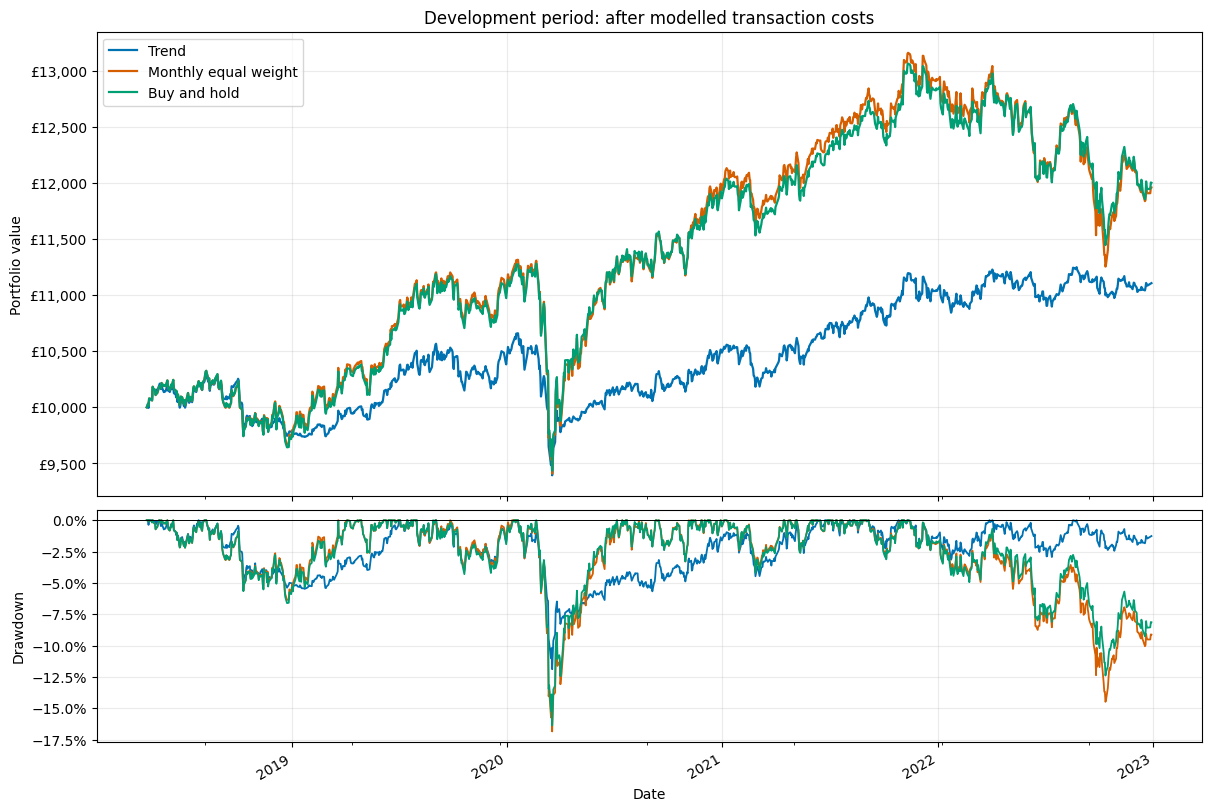

In [20]:
import etf_plotting

importlib.reload(etf_plotting)

fig, axes = etf_plotting.plot_equity_and_drawdown(
    development_equity,
    initial_capital_gbp=BACKTEST["initial_capital_gbp"],
    start_date=development_schedule.index[0],
    title="Development period: after modelled transaction costs",
)

Passive basket target: 64.3%
Cash target: 35.7%


,final_value_gbp,annualised_vol_pct,max_drawdown_pct
trend,11106.63,6.23,-11.88
Passive + cash,11269.05,6.20,-10.99


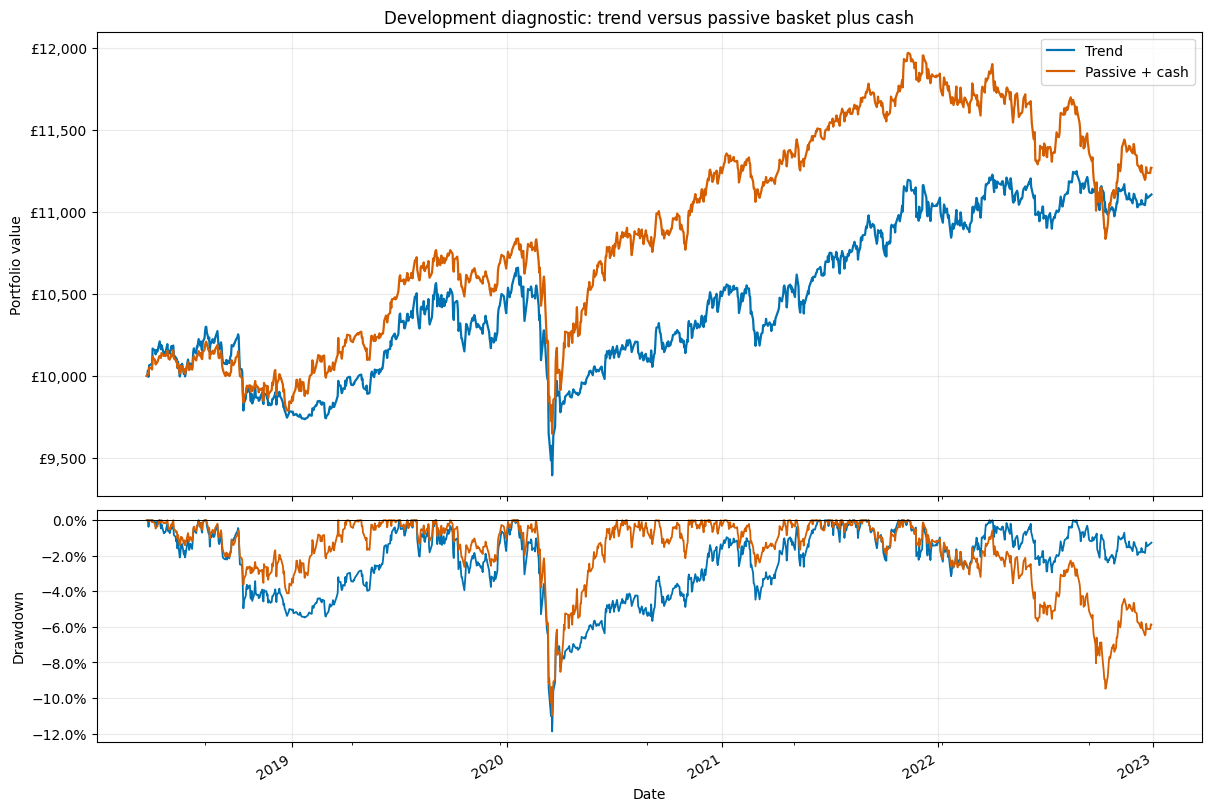

In [21]:
passive_daily = benchmark_results["monthly_equal_weight"]["daily"]

trend_vol = development_daily["net_return"].std(ddof=1)
passive_vol = passive_daily["net_return"].std(ddof=1)

passive_fraction = trend_vol / passive_vol

if not 0 <= passive_fraction <= 1:
    raise ValueError("The volatility ratio requires an allocation outside 0–100%.")

cash_benchmark_weights = passive_weights.copy()
cash_benchmark_weights.loc[:, adjusted_open.columns] *= passive_fraction
cash_benchmark_weights["CASH"] = 1 - passive_fraction

cash_benchmark_result = etf_backtest.run_backtest(
    open_prices=adjusted_open.loc[development_dates],
    close_prices=adjusted_close.loc[development_dates],
    execution_weights=cash_benchmark_weights,
    **BACKTEST,
)

cash_benchmark_daily = cash_benchmark_result["daily"]

comparison_equity = pd.DataFrame({
    "trend": development_daily["nav_close"],
    "Passive + cash": cash_benchmark_daily["nav_close"],
})

comparison_returns = pd.DataFrame({
    "trend": development_daily["net_return"],
    "Passive + cash": cash_benchmark_daily["net_return"],
})

# Include initial capital when identifying previous portfolio peaks.
comparison_peaks = comparison_equity.cummax().clip(
    lower=BACKTEST["initial_capital_gbp"]
)
comparison_drawdowns = comparison_equity / comparison_peaks - 1

print(f"Passive basket target: {passive_fraction:.1%}")
print(f"Cash target: {1 - passive_fraction:.1%}")

display(
    pd.DataFrame({
        "final_value_gbp": comparison_equity.iloc[-1],
        "annualised_vol_pct": (
            comparison_returns.std(ddof=1) * np.sqrt(252) * 100
        ),
        "max_drawdown_pct": comparison_drawdowns.min() * 100,
    }).round(2)
)

fig, axes = etf_plotting.plot_equity_and_drawdown(
    comparison_equity,
    initial_capital_gbp=BACKTEST["initial_capital_gbp"],
    start_date=development_schedule.index[0],
    title="Development diagnostic: trend versus passive basket plus cash",
)

In [22]:
annual_comparison = (1 + comparison_returns).groupby(comparison_returns.index.year).prod().sub(1).mul(100)
annual_comparison["trend_excess_pp"] = annual_comparison["trend"] - annual_comparison["Passive + cash"]
trend_cash_fraction = development_daily["cash"] / development_daily["nav_close"]
annual_comparison["mean_trend_cash_pct"] = trend_cash_fraction.groupby(trend_cash_fraction.index.year).mean().mul(100)

annual_comparison.index.name = "year"
display(annual_comparison.round(2))

,trend,Passive + cash,trend_excess_pp,mean_trend_cash_pct
year,,,,
2018,-2.17,-1.66,-0.52,36.86
2019,6.13,8.34,-2.21,26.52
2020,1.01,5.46,-4.46,33.68
2021,5.25,5.25,-0.01,24.20
2022,0.63,-4.72,5.34,55.01


In [23]:
import etf_validation

importlib.reload(etf_validation)

LOOKBACK_MONTHS = (3, 6, 9, 12)

sweep_summary, sweep_results = etf_validation.run_lookback_sweep(
    monthly_prices=monthly_prices.loc[
        monthly_prices.index < HOLDOUT_START
    ],
    open_prices=adjusted_open.loc[development_dates],
    close_prices=adjusted_close.loc[development_dates],
    decision_schedule=development_schedule,
    lookbacks=LOOKBACK_MONTHS,
    **BACKTEST,
)

# The sweep's baseline must reproduce our existing daily results.
pd.testing.assert_frame_equal(
    sweep_results[12]["daily"],
    development_daily,
)

display(sweep_summary.round(2))

,final_value_gbp,cagr_pct,annualised_vol_pct,max_drawdown_pct,mean_cash_pct,total_cost_gbp,rebalances
lookback_months,,,,,,,
3,11437.79,2.92,5.67,-7.52,41.13,152.06,56
6,11517.42,3.07,5.39,-6.38,40.60,109.65,56
9,10806.42,1.68,5.82,-10.28,38.23,99.31,56
12,11106.63,2.27,6.23,-11.88,35.09,87.31,56


In [ ]:
FINAL_LOOKBACK = 6

candidate_returns = sweep_results[FINAL_LOOKBACK]["daily"]["net_return"]
reference_returns = benchmark_results["monthly_equal_weight"]["daily"][
    "net_return"
]

final_passive_fraction = float(
    candidate_returns.std(ddof=1) / reference_returns.std(ddof=1)
)

if not 0 <= final_passive_fraction <= 1:
    raise ValueError("The passive allocation must lie between 0 and 1.")

FINAL_SPEC = {
    "lookback_months": FINAL_LOOKBACK,
    "passive_fraction": final_passive_fraction,
    "holdout_start": HOLDOUT_START.strftime("%Y-%m-%d"),
    "holdout_end_exclusive": DATA_END,
    **BACKTEST,
}

display(pd.Series(FINAL_SPEC, name="frozen_specification"))

lookback_months                   6
passive_fraction           0.556653
holdout_start            2023-01-01
holdout_end_exclusive    2026-09-01
initial_capital_gbp         10000.0
cost_per_side_bps              10.0
cash_rate_annual                0.0
Name: frozen_specification, dtype: object

In [25]:
importlib.reload(etf_data)

holdout_start = pd.Timestamp(FINAL_SPEC["holdout_start"])
holdout_end = pd.Timestamp(FINAL_SPEC["holdout_end_exclusive"])

holdout_schedule = executable_schedule.loc[
    executable_schedule["execution_date"].ge(holdout_start)
    & executable_schedule["execution_date"].lt(holdout_end)
].copy()

holdout_dates = adjusted_open.index[
    (adjusted_open.index >= holdout_schedule["execution_date"].iloc[0])
    & (adjusted_open.index < holdout_end)
]

excluded_holdout = pd.DataFrame({
    ticker: aligned_histories[ticker].loc[holdout_dates, "quote_excluded"]
    for ticker in adjusted_open.columns
})

(
    holdout_open_marks,
    holdout_close_marks,
    holdout_stale_quotes,
) = etf_data.prepare_valuation_marks(
    adjusted_open.loc[holdout_dates],
    adjusted_close.loc[holdout_dates],
    excluded_holdout,
    execution_dates=holdout_schedule["execution_date"],
)

display(holdout_stale_quotes.sum().rename("stale_quote_sessions"))

print(
    "Flagged dates:",
    holdout_stale_quotes.index[
        holdout_stale_quotes.any(axis=1)
    ].strftime("%Y-%m-%d").tolist(),
)

IUSA    0
ISF     0
IEUX    0
IJPN    1
IEEM    0
IGLT    0
INXG    0
SLXX    0
SGLN    0
CMOP    1
Name: stale_quote_sessions, dtype: int64

Flagged dates: ['2025-10-24']


trend             13325.30
Passive + cash    12462.23
Name: final_value_gbp, dtype: float64

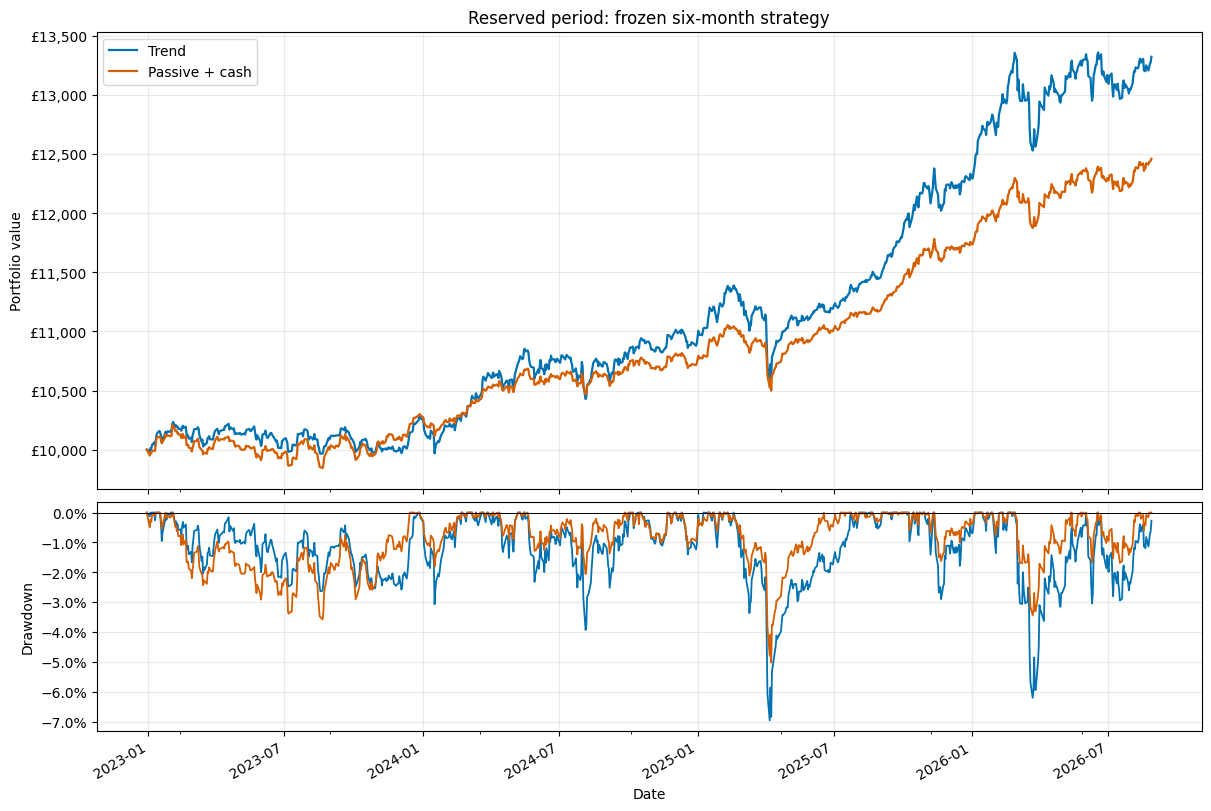

In [26]:
EVALUATION_SETTINGS = {
    "bootstrap_block_months": 3,
    "bootstrap_samples": 10_000,
    "confidence_level": 0.95,
    "seed": 42,
    "cost_scenarios_bps": (5.0, 10.0, 20.0),
}

importlib.reload(etf_validation)

holdout_results = etf_validation.run_frozen_evaluation(
    monthly_prices=monthly_prices,
    open_prices=adjusted_open.loc[holdout_dates],
    close_prices=adjusted_close.loc[holdout_dates],
    decision_schedule=holdout_schedule,
    excluded_quotes=excluded_holdout,
    spec=FINAL_SPEC,
)

holdout_equity = pd.DataFrame({
    "trend": holdout_results["trend"]["daily"]["nav_close"],
    "Passive + cash": holdout_results["passive_cash"]["daily"]["nav_close"],
})

holdout_returns = pd.DataFrame({
    "trend": holdout_results["trend"]["daily"]["net_return"],
    "Passive + cash": holdout_results["passive_cash"]["daily"]["net_return"],
})

display(holdout_equity.iloc[-1].round(2).rename("final_value_gbp"))

fig, axes = etf_plotting.plot_equity_and_drawdown(
    holdout_equity,
    initial_capital_gbp=FINAL_SPEC["initial_capital_gbp"],
    start_date=holdout_schedule.index[0],
    title="Reserved period: frozen six-month strategy",
)

In [27]:
importlib.reload(etf_validation)

assert holdout_returns.index.equals(holdout_dates)
assert np.isfinite(holdout_returns.to_numpy()).all()

holdout_monthly_returns = (
    (1 + holdout_returns)
    .groupby(holdout_returns.index.to_period("M"))
    .prod()
    - 1
)

holdout_monthly_excess = (
    holdout_monthly_returns["trend"]
    - holdout_monthly_returns["Passive + cash"]
).rename("net_excess")

holdout_inference = etf_validation.bootstrap_mean_excess(
    holdout_monthly_excess,
    block_months=EVALUATION_SETTINGS["bootstrap_block_months"],
    n_bootstrap=EVALUATION_SETTINGS["bootstrap_samples"],
    confidence_level=EVALUATION_SETTINGS["confidence_level"],
    seed=EVALUATION_SETTINGS["seed"],
)

display(holdout_inference.round(4))

months                     44.0000
mean_monthly_excess_bps    16.0797
lower_ci_bps               -2.6714
upper_ci_bps               32.8439
one_sided_p_value           0.0448
dtype: float64

In [28]:
importlib.reload(etf_validation)

holdout_cost_summary, holdout_cost_runs = (
    etf_validation.run_cost_sensitivity(
        monthly_prices=monthly_prices,
        open_prices=adjusted_open.loc[holdout_dates],
        close_prices=adjusted_close.loc[holdout_dates],
        decision_schedule=holdout_schedule,
        excluded_quotes=excluded_holdout,
        spec=FINAL_SPEC,
        evaluation_settings=EVALUATION_SETTINGS,
    )
)

# The original cost scenario must reproduce the original portfolios.
for name, original in holdout_results.items():
    pd.testing.assert_frame_equal(
        holdout_cost_runs[FINAL_SPEC["cost_per_side_bps"]][name]["daily"],
        original["daily"],
    )

display(holdout_cost_summary.round(4))

,trend_final_gbp,benchmark_final_gbp,trend_cost_gbp,benchmark_cost_gbp,mean_monthly_excess_bps,lower_ci_bps,upper_ci_bps,one_sided_p_value
cost_per_side_bps,,,,,,,,
5.0,13382.1939,12468.8774,46.8305,5.5746,16.9333,-1.6961,33.5820,0.0364
10.0,13325.2997,12462.2332,93.4534,11.1454,16.0797,-2.6714,32.8439,0.0448
20.0,13212.2304,12448.9580,186.0804,22.2760,14.3727,-4.6382,31.3524,0.0670
